# Capstone Project: Sistem Deteksi Website Phishing
## Notebook 01 - EDA, Preprocessing, Modeling & Evaluation

**Mata Kuliah**: Pembelajaran Mesin — UAS Genap 2025/2026 
**Dataset**: Web Page Phishing Detection Dataset (Hannousse & Yahiouche, 2021) — 11.430 URL, 87 fitur 
**Algoritma**: Decision Tree & Random Forest (perbandingan 2 model)

---
## 1. Problem Definition & Data Acquisition

### 1.1 Problem Statement

Phishing merupakan salah satu bentuk kejahatan siber paling umum, di mana pelaku membuat website palsu yang menyerupai website resmi (perbankan, e-commerce, layanan email) untuk mencuri kredensial login, data kartu kredit, atau informasi pribadi korban. Pendekatan konvensional berbasis blacklist tidak efektif mendeteksi website phishing baru yang belum terdaftar, sehingga dibutuhkan pendekatan berbasis Machine Learning yang mampu mempelajari pola karakteristik URL dan konten halaman untuk mendeteksi phishing secara adaptif, termasuk pada website yang baru dibuat.

Proyek ini bertujuan membangun model klasifikasi biner untuk memprediksi apakah sebuah website tergolong **phishing** atau **legitimate**, berdasarkan 87 fitur yang diekstraksi dari struktur URL (56 fitur), konten halaman HTML (24 fitur), dan reputasi domain dari layanan eksternal (7 fitur). Model yang dihasilkan diharapkan dapat digunakan sebagai komponen deteksi otomatis pada sistem keamanan siber, misalnya sebagai filter tambahan pada browser atau email gateway.

**Tujuan bisnis/analisis:**
- Meminimalkan false negative (phishing yang tidak terdeteksi), karena risiko keamanannya jauh lebih besar dibanding false positive.
- Memberikan interpretasi fitur yang dapat digunakan tim keamanan untuk memahami pola phishing terkini.

**Metrik kesuksesan proyek**: Accuracy > 95%, F1-Score > 0.95, AUC-ROC > 0.95 pada data uji.

### 1.2 Sumber Dataset

Dataset bersumber dari studi **Hannousse, A. & Yahiouche, S. (2021), "Towards benchmark datasets for machine learning based website phishing detection: An experimental study", Engineering Applications of Artificial Intelligence**, dipublikasikan di Mendeley Data: https://data.mendeley.com/datasets/c2gw7fy2j4/3 (juga tersedia di Kaggle: "Web Page Phishing Detection Dataset"). Dataset dikumpulkan dari URL legitimate (Alexa, Yandex) dan URL phishing (PhishTank, OpenPhish), dengan fitur diekstraksi secara otomatis menggunakan skrip Python pada Mei 2020.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, roc_curve, roc_auc_score)
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
df = pd.read_csv('../data/raw/dataset_phishing.csv')
print('Ukuran dataset:', df.shape)
df.head()

Ukuran dataset: (11430, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  str    
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  11430 non-null

In [4]:
# Statistik deskriptif awal
df.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
length_url,11430.0,61.126684,55.297318,12.0,33.0,47.0,71.0,1641.0
length_hostname,11430.0,21.090289,10.777171,4.0,15.0,19.0,24.0,214.0
ip,11430.0,0.150569,0.357644,0.0,0.0,0.0,0.0,1.0
nb_dots,11430.0,2.480752,1.369686,1.0,2.0,2.0,3.0,24.0
nb_hyphens,11430.0,0.997550,2.087087,0.0,0.0,0.0,1.0,43.0
nb_at,11430.0,0.022222,0.155500,0.0,0.0,0.0,0.0,4.0
nb_qm,11430.0,0.141207,0.364456,0.0,0.0,0.0,0.0,3.0
nb_and,11430.0,0.162292,0.821337,0.0,0.0,0.0,0.0,19.0
nb_or,11430.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
nb_eq,11430.0,0.293176,0.998317,0.0,0.0,0.0,0.0,19.0


**Statistik deskriptif awal:** Dataset terdiri dari **11.430 baris** dan **89 kolom** (1 kolom `url`, 87 fitur numerik, dan 1 kolom target `status`). Seluruh fitur bertipe numerik (int64/float64) kecuali kolom `url` yang bertipe teks/identifier.

---
## 2. Exploratory Data Analysis & Preprocessing

### 2.1 Analisis Kualitas Data (Missing Values, Duplikat, Outlier)

In [5]:
# Missing values
print('Total missing values:', df.isnull().sum().sum())

# Duplikat
print('Jumlah baris duplikat:', df.duplicated().sum())

Total missing values: 0
Jumlah baris duplikat: 0


Tidak ditemukan missing value maupun baris duplikat pada dataset, sehingga tidak diperlukan imputasi maupun deduplikasi.

In [6]:
# Deteksi outlier menggunakan metode IQR pada beberapa fitur numerik kunci
num_cols_check = ['length_url', 'length_hostname', 'nb_hyperlinks', 'web_traffic', 'domain_age']
outlier_summary = {}
for c in num_cols_check:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_summary[c] = ((df[c] < lo) | (df[c] > hi)).sum()

pd.Series(outlier_summary, name='Jumlah Outlier (IQR method)')

length_url          620
length_hostname     775
nb_hyperlinks       953
web_traffic        2138
domain_age            0
Name: Jumlah Outlier (IQR method), dtype: int64

Beberapa fitur seperti `web_traffic` dan `nb_hyperlinks` menunjukkan cukup banyak outlier, namun nilai-nilai tersebut **tidak dihapus** karena outlier pada fitur ini justru merupakan sinyal penting (misalnya traffic sangat rendah adalah indikasi kuat website phishing), bukan noise atau kesalahan input.

### 2.2 Analisis Univariat: Distribusi Kelas Target

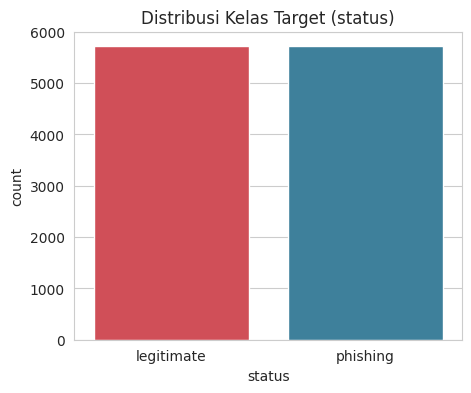

status
legitimate    5715
phishing      5715
Name: count, dtype: int64
status
legitimate    50.0
phishing      50.0
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(5,4))
sns.countplot(x='status', data=df, hue='status', palette=['#E63946','#2E86AB'], legend=False)
plt.title('Distribusi Kelas Target (status)')
plt.show()

print(df['status'].value_counts())
print(df['status'].value_counts(normalize=True)*100)

**Insight 1:** Dataset seimbang sempurna (50% legitimate : 50% phishing), sehingga tidak diperlukan teknik balancing tambahan seperti SMOTE.

### 2.3 Analisis Univariat: Distribusi Panjang URL berdasarkan Status

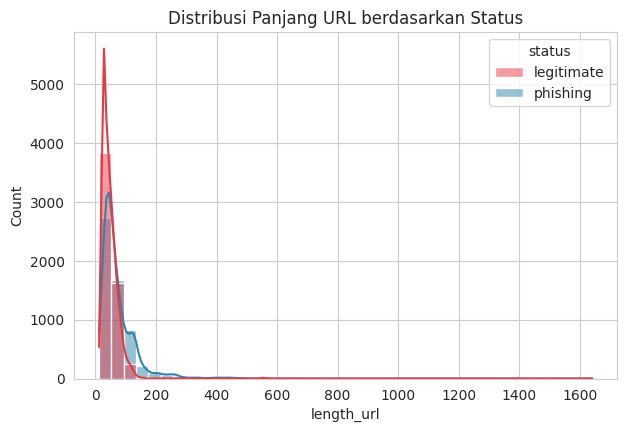

Rata-rata panjang URL - phishing  : 74.87
Rata-rata panjang URL - legitimate: 47.38


In [8]:
plt.figure(figsize=(7,4.5))
sns.histplot(data=df, x='length_url', hue='status', bins=40, kde=True, palette=['#E63946','#2E86AB'])
plt.title('Distribusi Panjang URL berdasarkan Status')
plt.show()

print('Rata-rata panjang URL - phishing  :', df[df.status=='phishing']['length_url'].mean().round(2))
print('Rata-rata panjang URL - legitimate:', df[df.status=='legitimate']['length_url'].mean().round(2))

**Insight 2:** URL phishing secara rata-rata jauh lebih panjang (~75 karakter) dibanding URL legitimate (~47 karakter). Pelaku phishing cenderung menyisipkan parameter/subdomain tambahan untuk menyamarkan URL asli.

### 2.4 Analisis Multivariat: Correlation Matrix Fitur Kunci

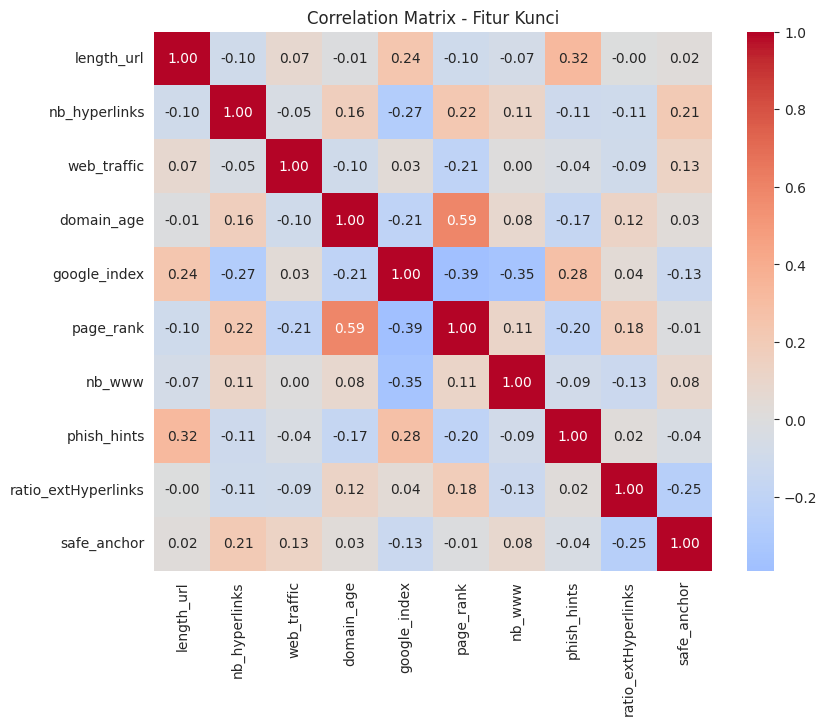

In [9]:
key_feats = ['length_url','nb_hyperlinks','web_traffic','domain_age','google_index',
             'page_rank','nb_www','phish_hints','ratio_extHyperlinks','safe_anchor']

plt.figure(figsize=(9,7))
sns.heatmap(df[key_feats].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Fitur Kunci')
plt.show()

**Insight 3:** `ratio_extHyperlinks` dan `safe_anchor` berkorelasi negatif cukup kuat, mengindikasikan halaman dengan banyak link eksternal cenderung memiliki lebih sedikit anchor 'aman' — pola umum pada halaman phishing yang mengarahkan pengguna ke domain lain.

### 2.5 Analisis Kategorikal: google_index vs Status

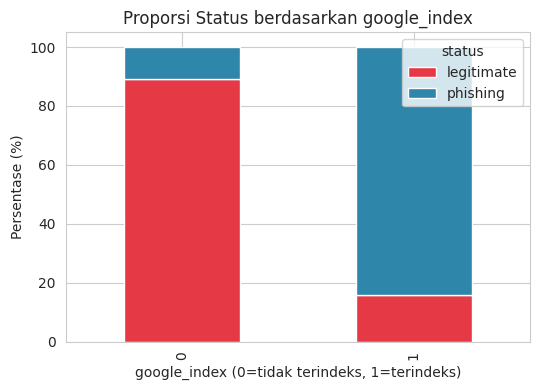

status,legitimate,phishing
google_index,,
0,89.130843,10.869157
1,15.844667,84.155333


In [10]:
ctab = pd.crosstab(df['google_index'], df['status'], normalize='index') * 100
ctab.plot(kind='bar', stacked=True, color=['#E63946','#2E86AB'], figsize=(5.5,4))
plt.title('Proporsi Status berdasarkan google_index')
plt.ylabel('Persentase (%)')
plt.xlabel('google_index (0=tidak terindeks, 1=terindeks)')
plt.legend(title='status')
plt.tight_layout()
plt.show()

ctab

**Insight 4:** Website yang tidak terindeks Google (`google_index=0`) memiliki proporsi phishing yang sangat dominan, mengonfirmasi bahwa indeksasi mesin pencari adalah sinyal reputasi domain yang kuat.

### 2.6 Insight ke-5: Ringkasan Fitur Reputasi Domain

In [11]:
reputation_feats = ['domain_age','web_traffic','google_index','page_rank']
df.groupby('status')[reputation_feats].mean()

,domain_age,web_traffic,google_index,page_rank
status,,,,
legitimate,5093.938408,736251.807874,0.169204,4.482415
phishing,3031.149081,977261.478740,0.898688,1.889064


**Insight 5:** Rata-rata `domain_age` (usia domain) dan `web_traffic` pada kelas legitimate jauh lebih tinggi dibanding phishing, mengonfirmasi bahwa domain phishing umumnya baru dibuat dan memiliki traffic organik yang sangat rendah.

### 2.7 Feature Engineering & Preprocessing

Langkah preprocessing yang dilakukan:
1. **Drop kolom `url`** — bersifat identifier/teks bebas, berpotensi menyebabkan data leakage bila digunakan langsung.
2. **Label Encoding** pada kolom target `status` (`legitimate`→0, `phishing`→1).
3. **Feature scaling** menggunakan `StandardScaler` (disimpan sebagai `scaler.pkl` untuk keperluan deployment;    Decision Tree dan Random Forest sendiri tidak sensitif terhadap skala, namun scaler disiapkan agar pipeline    dapat digunakan kembali untuk algoritma lain yang sensitif terhadap skala).
4. **Train-test split** 80:20 dengan `stratify=y` agar proporsi kelas tetap seimbang di kedua subset.

In [12]:
le = LabelEncoder()
df['status_encoded'] = le.fit_transform(df['status'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

df_model = df.drop(columns=['url', 'status'])
X = df_model.drop(columns=['status_encoded'])
y = df_model['status_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape, ' Test size:', X_test.shape)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)
joblib.dump(scaler, '../models/scaler.pkl')
print('Scaler disimpan.')

Label mapping: {'legitimate': np.int64(0), 'phishing': np.int64(1)}
Train size: (9144, 87)  Test size: (2286, 87)
Scaler disimpan.


---
## 3. Modeling & Evaluation

Dua algoritma diimplementasikan dan dibandingkan: **Decision Tree** (model sederhana, mudah diinterpretasikan) dan **Random Forest** (model ensemble, umumnya lebih akurat dan tahan overfitting).

### 3.1 Decision Tree — Baseline

In [13]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
y_pred_dt = dt_base.predict(X_test)

print('===== Decision Tree (Baseline) =====')
print('Accuracy:', accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, target_names=['legitimate','phishing']))

===== Decision Tree (Baseline) =====
Accuracy: 0.9339457567804025
              precision    recall  f1-score   support

  legitimate       0.94      0.93      0.93      1143
    phishing       0.93      0.94      0.93      1143

    accuracy                           0.93      2286
   macro avg       0.93      0.93      0.93      2286
weighted avg       0.93      0.93      0.93      2286



### 3.2 Decision Tree — Hyperparameter Tuning (GridSearchCV)

In [14]:
param_grid_dt = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)
y_prob_best_dt = best_dt.predict_proba(X_test)[:,1]

print('Best Parameters (Decision Tree):', grid_dt.best_params_)
print('Best CV Accuracy:', grid_dt.best_score_)
print()
print(classification_report(y_test, y_pred_best_dt, target_names=['legitimate','phishing']))

Best Parameters (Decision Tree): {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV Accuracy: 0.9390863584864804

              precision    recall  f1-score   support

  legitimate       0.94      0.92      0.93      1143
    phishing       0.92      0.94      0.93      1143

    accuracy                           0.93      2286
   macro avg       0.93      0.93      0.93      2286
weighted avg       0.93      0.93      0.93      2286



### 3.3 Random Forest — Baseline

In [15]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)

print('===== Random Forest (Baseline) =====')
print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=['legitimate','phishing']))

===== Random Forest (Baseline) =====
Accuracy: 0.9593175853018373
              precision    recall  f1-score   support

  legitimate       0.96      0.95      0.96      1143
    phishing       0.95      0.96      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



### 3.4 Random Forest — Hyperparameter Tuning (GridSearchCV)

In [16]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:,1]

print('Best Parameters (Random Forest):', grid_rf.best_params_)
print('Best CV Accuracy:', grid_rf.best_score_)
print()
print(classification_report(y_test, y_pred_best_rf, target_names=['legitimate','phishing']))

Best Parameters (Random Forest): {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Accuracy: 0.9673008292127921

              precision    recall  f1-score   support

  legitimate       0.97      0.96      0.96      1143
    phishing       0.96      0.97      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



### 3.5 Cross Validation Stabilitas Model (Random Forest)

In [17]:
cv_scores_rf = cross_val_score(best_rf, X, y, cv=10, scoring='accuracy')
print('10-Fold CV Accuracy:', cv_scores_rf)
print('Mean Accuracy:', cv_scores_rf.mean())
print('Std:', cv_scores_rf.std())

10-Fold CV Accuracy: [0.97025372 0.96587927 0.96762905 0.9720035  0.9623797  0.96937883
 0.95800525 0.96412948 0.9720035  0.9720035 ]
Mean Accuracy: 0.9673665791776026
Std: 0.00449612079003661


### 3.6 Confusion Matrix

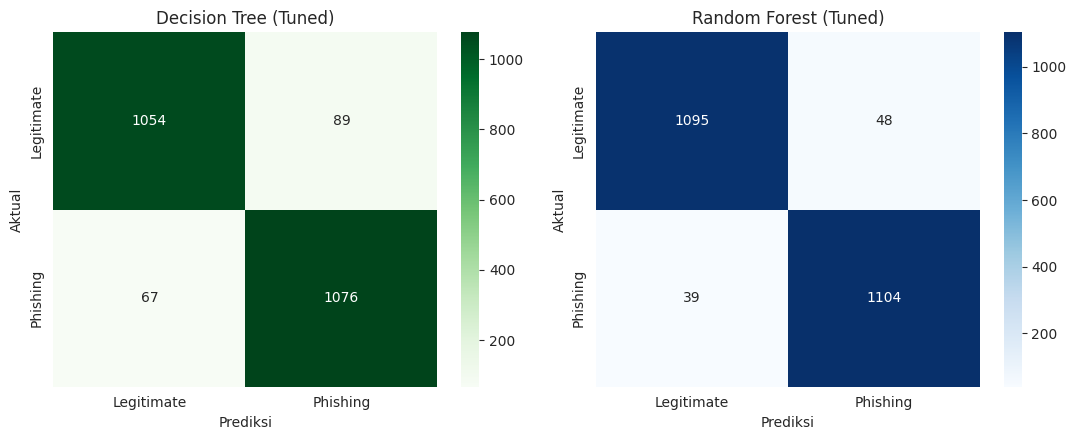

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

cm_dt = confusion_matrix(y_test, y_pred_best_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Legitimate','Phishing'], yticklabels=['Legitimate','Phishing'])
axes[0].set_title('Decision Tree (Tuned)')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

cm_rf = confusion_matrix(y_test, y_pred_best_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Legitimate','Phishing'], yticklabels=['Legitimate','Phishing'])
axes[1].set_title('Random Forest (Tuned)')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

### 3.7 Kurva ROC & AUC

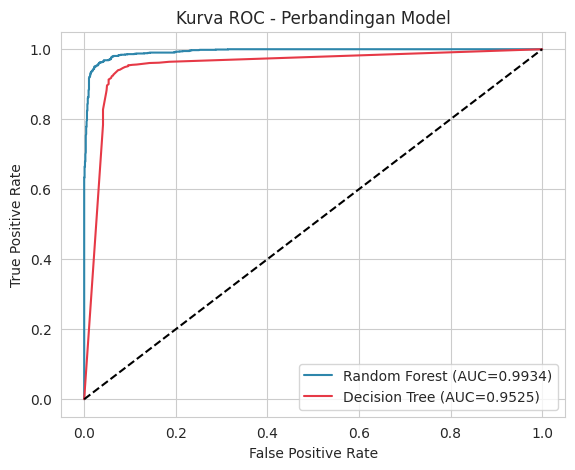

AUC Decision Tree : 0.9524677197502545
AUC Random Forest : 0.9933943077762699


In [19]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_best_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_best_rf)
auc_dt = roc_auc_score(y_test, y_prob_best_dt)
auc_rf = roc_auc_score(y_test, y_prob_best_rf)

plt.figure(figsize=(6.5,5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.4f})', color='#2E86AB')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={auc_dt:.4f})', color='#E63946')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Kurva ROC - Perbandingan Model')
plt.legend()
plt.show()

print('AUC Decision Tree :', auc_dt)
print('AUC Random Forest :', auc_rf)

### 3.8 Feature Importance — Random Forest (Model Terbaik)

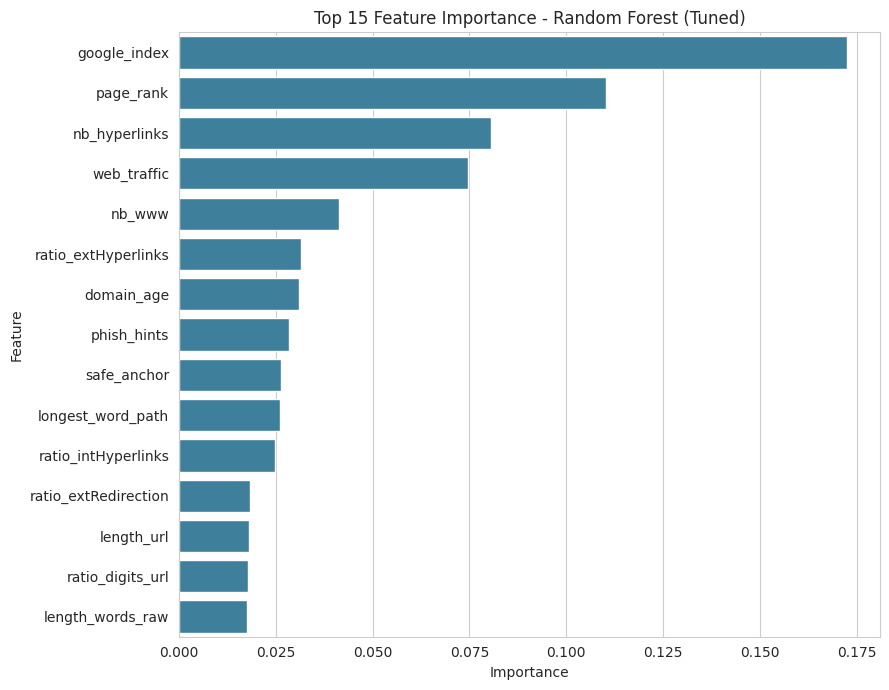

,Feature,Importance
85,google_index,0.172385
86,page_rank,0.110274
56,nb_hyperlinks,0.080581
83,web_traffic,0.074535
20,nb_www,0.041417
58,ratio_extHyperlinks,0.031542
82,domain_age,0.030955
50,phish_hints,0.028515
74,safe_anchor,0.026247
46,longest_word_path,0.026052


In [20]:
fi_rf = pd.DataFrame({'Feature': X.columns, 'Importance': best_rf.feature_importances_}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9,7))
sns.barplot(data=fi_rf.head(15), x='Importance', y='Feature', color='#2E86AB')
plt.title('Top 15 Feature Importance - Random Forest (Tuned)')
plt.tight_layout()
plt.show()

fi_rf.head(10)

### 3.9 Interpretasi Model dengan SHAP

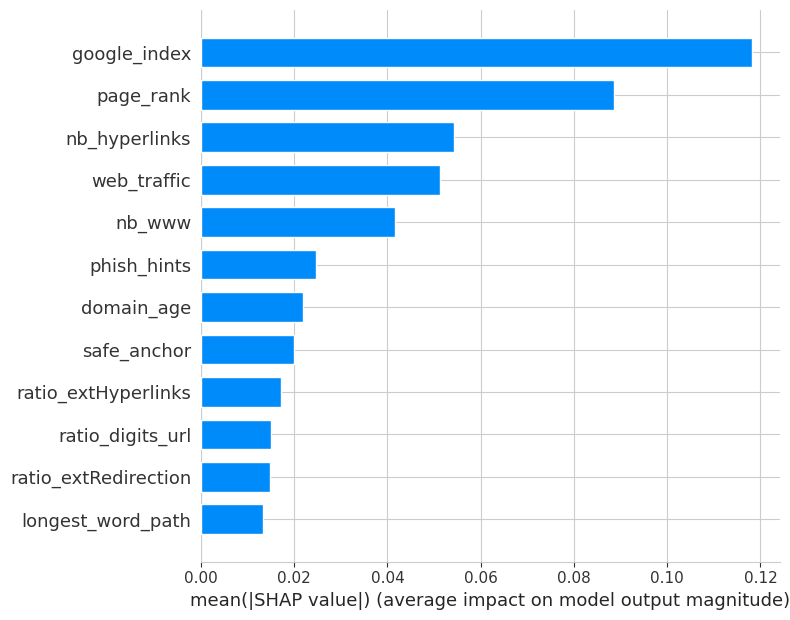

In [21]:
import shap

explainer = shap.TreeExplainer(best_rf)
sample = X_test.sample(n=min(300, len(X_test)), random_state=42)
shap_values = explainer.shap_values(sample)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values
if sv.ndim == 3:
    sv = sv[:, :, 1]

shap.summary_plot(sv, sample, plot_type='bar', max_display=12)

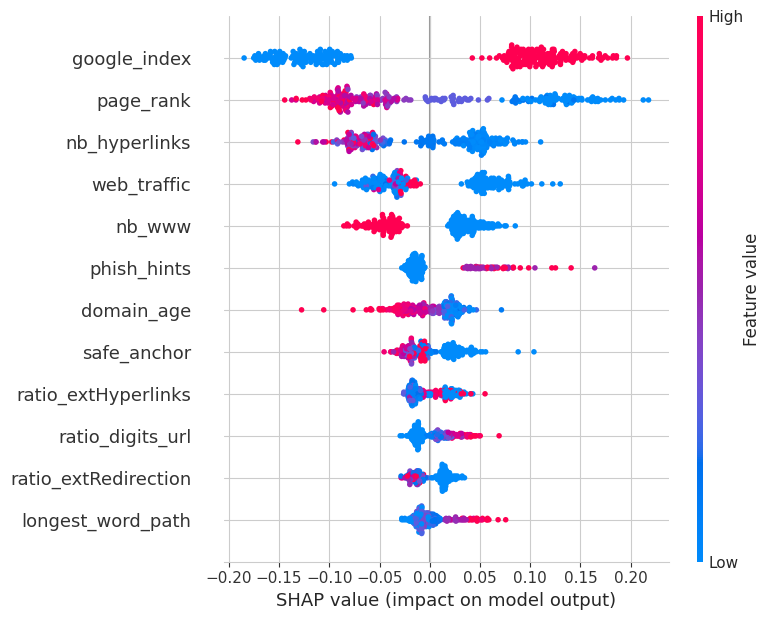

In [22]:
shap.summary_plot(sv, sample, max_display=12)

**Interpretasi SHAP:** Nilai SHAP mengonfirmasi hasil feature importance Random Forest — `google_index`, `page_rank`, `nb_hyperlinks`, dan `web_traffic` adalah pendorong utama prediksi model. Nilai `google_index` yang rendah (warna biru pada beeswarm plot) secara konsisten mendorong prediksi ke arah kelas phishing (SHAP value positif), sejalan dengan insight EDA sebelumnya.

### 3.10 Tabel Perbandingan Performa Semua Model

In [23]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree (Baseline)', 'Decision Tree (Tuned)',
              'Random Forest (Baseline)', 'Random Forest (Tuned)'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_best_dt),
                 accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_best_rf)],
    'Precision': [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_best_dt),
                  precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_best_rf)],
    'Recall': [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_best_dt),
               recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_best_rf)],
    'F1-Score': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_best_dt),
                 f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_best_rf)],
    'AUC-ROC': [roc_auc_score(y_test, dt_base.predict_proba(X_test)[:,1]), auc_dt,
                roc_auc_score(y_test, rf_base.predict_proba(X_test)[:,1]), auc_rf]
})

comparison = comparison.sort_values('F1-Score', ascending=False).reset_index(drop=True)
comparison

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Random Forest (Tuned),0.961942,0.958333,0.965879,0.962092,0.993394
1,Random Forest (Baseline),0.959318,0.954939,0.964129,0.959512,0.993471
2,Decision Tree (Baseline),0.933946,0.929066,0.939633,0.934319,0.933946
3,Decision Tree (Tuned),0.931759,0.923605,0.941382,0.932409,0.952468


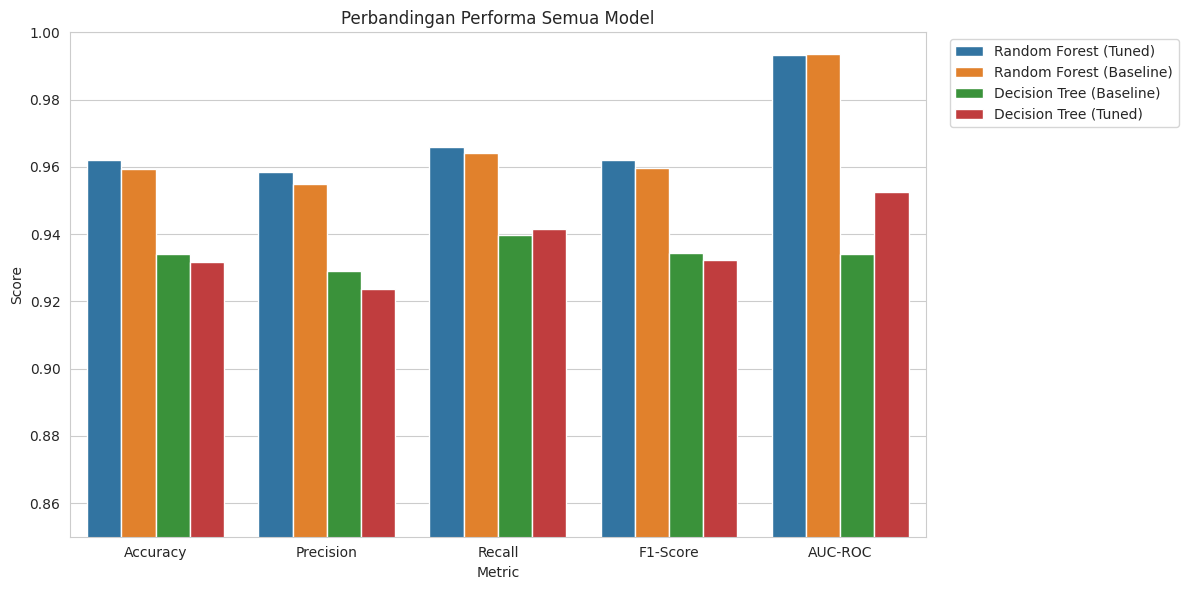

In [24]:
melt = comparison.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(12,6))
sns.barplot(data=melt, x='Metric', y='Score', hue='Model')
plt.ylim(0.85, 1.0)
plt.title('Perbandingan Performa Semua Model')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

comparison.to_csv('../data/processed/model_comparison.csv', index=False)

### 3.11 Pemilihan Model Terbaik

Berdasarkan tabel perbandingan di atas, **Random Forest (Tuned)** dipilih sebagai model terbaik karena:

1. Accuracy, Precision, Recall, F1-Score, dan AUC-ROC lebih tinggi secara konsisten dibanding Decision Tree pada seluruh metrik.
2. Sebagai model ensemble, Random Forest lebih tahan terhadap overfitting dibanding single Decision Tree,    khususnya pada dataset dengan 87 fitur.
3. AUC-ROC mendekati 0.99, menandakan model sangat andal membedakan kedua kelas pada berbagai threshold.

Decision Tree tetap bernilai sebagai model pembanding karena struktur pohonnya lebih sederhana dan mudah diinterpretasikan langsung (single tree), sehingga cocok sebagai baseline penjelas cepat.

### 3.12 Menyimpan Model Final

In [25]:
joblib.dump(best_rf, '../models/best_random_forest.pkl')
joblib.dump(best_dt, '../models/best_decision_tree.pkl')
joblib.dump(list(X.columns), '../models/feature_columns.pkl')

print('Model Random Forest terbaik berhasil disimpan ke ../models/best_random_forest.pkl')
print('Model Decision Tree terbaik berhasil disimpan ke ../models/best_decision_tree.pkl')

Model Random Forest terbaik berhasil disimpan ke ../models/best_random_forest.pkl
Model Decision Tree terbaik berhasil disimpan ke ../models/best_decision_tree.pkl
